# Nodes characterization

This notebook loads every CSV matching `data/characterization-node*.csv`, removes non-numeric summary rows,
and plots:

1. Per-dataset curves for power and error versus central frequency.
2. Aggregate mean and standard deviation across datasets.


In [4]:
from pathlib import Path
from typing import Dict
import re

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def resolve_data_dir(
    relative_dir: str = "data",  # Expected relative data directory name
) -> Path:                        # Resolved existing data directory path
    '''
    Resolve the dataset directory independently from notebook execution cwd.

    Purpose:
        Support running the notebook both from the repository root and from
        the `notebooks/` directory used by some notebook executors.
    Parameters:
        relative_dir: Relative directory name for CSV data.
    Returns:
        Existing data directory path.
    Side effects:
        Reads directory metadata from disk.
    Assumptions:
        The repository uses either `<repo>/data` or `<repo>/notebooks/../data`.
    '''
    current_dir = Path.cwd()

    # Check the two expected execution contexts for this repository layout.
    candidate_dirs = (
        current_dir / relative_dir,
        current_dir.parent / relative_dir,
    )
    for candidate_dir in candidate_dirs:
        if candidate_dir.exists() and candidate_dir.is_dir():
            return candidate_dir

    checked_paths = ", ".join(str(path) for path in candidate_dirs)
    raise FileNotFoundError(f"Could not locate data directory. Checked: {checked_paths}")

DATA_DIR = resolve_data_dir("data")
CSV_PATTERN = "characterization-node*.csv"
REQUIRED_COLUMNS = ("central_freq_hz", "pwr_dBm", "error_dB")

plt.style.use("default")


In [5]:
def _run_index_from_name(
    csv_path: Path,  # CSV file path to parse
) -> int:          # Numeric index used for deterministic sorting
    """Extracts the numeric run id from names like characterization-node10.csv."""
    match = re.search(r"(\d+)$", csv_path.stem)
    return int(match.group(1)) if match else 10**9


def read_csv_with_fallback(
    csv_path: Path,                                 # Path of CSV to read
    encodings: tuple[str, ...] = ("utf-8", "latin-1"),  # Encoding priority order
) -> pd.DataFrame:                                 # Parsed CSV dataframe
    '''
    Read a CSV trying multiple encodings until one succeeds.

    Purpose:
        Handle mixed-encoding files where some rows include accented
        characters that break strict UTF-8 decoding.
    Parameters:
        csv_path: Input CSV path.
        encodings: Candidate encodings evaluated in order.
    Returns:
        DataFrame produced by `pandas.read_csv`.
    Side effects:
        Reads one CSV from disk.
    Assumptions:
        At least one provided encoding is compatible with the file.
    '''
    last_error: Exception | None = None
    for encoding in encodings:
        try:
            return pd.read_csv(csv_path, encoding=encoding)
        except UnicodeDecodeError as error:
            last_error = error

    if last_error is not None:
        raise last_error
    raise RuntimeError(f"Failed to read CSV file: {csv_path}")


def load_power_error_csv(
    csv_path: Path,                               # Path of one CSV file
    required_columns: tuple[str, str, str] = REQUIRED_COLUMNS,  # Required schema
) -> pd.DataFrame:                               # Clean dataframe with numeric rows only
    '''
    Load one power-vs-error CSV and keep only numeric measurement rows.

    Purpose:
        Parse expected columns as numeric and remove non-measurement
        summary rows appended at file endings.
    Parameters:
        csv_path: Input CSV path.
        required_columns: Column names that must be present.
    Returns:
        DataFrame sorted by frequency with an added
        `Frecuencia_central_MHz` column.
    Side effects:
        Reads one CSV from disk.
    Assumptions:
        Frequency is stored in Hz and converted to MHz as Hz / 1e6.
    '''
    df_raw = read_csv_with_fallback(csv_path)

    # Validate schema early so failures are explicit.
    missing_columns = [col for col in required_columns if col not in df_raw.columns]
    if missing_columns:
        missing_text = ", ".join(missing_columns)
        raise ValueError(f"{csv_path.name}: missing required columns: {missing_text}")

    df = df_raw.loc[:, list(required_columns)].copy()

    # Keep only numeric measurement rows; this drops summary labels like Promedio/Varianza.
    for col in required_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=list(required_columns))

    # Enforce monotonic frequency for cleaner plots.
    df = df.sort_values("central_freq_hz").reset_index(drop=True)
    df["Frecuencia_central_MHz"] = df["central_freq_hz"] / 1e6
    return df


def load_all_power_error_csvs(
    data_dir: Path,                    # Directory containing CSV files
    pattern: str = CSV_PATTERN,        # Glob pattern for CSV discovery
) -> Dict[str, pd.DataFrame]:         # Mapping: dataset name -> cleaned dataframe
    '''
    Load every matching CSV from disk into a deterministic dictionary.

    Purpose:
        Build a complete in-memory dataset ready for comparative plotting.
    Parameters:
        data_dir: Root directory where CSV files live.
        pattern: Glob expression used to match files.
    Returns:
        Dictionary keyed by file stem (without extension).
    Side effects:
        Reads multiple CSV files from disk.
    Assumptions:
        Files follow the naming pattern `pwr_vs_error_<id>.csv`.
    '''
    csv_paths = sorted(
        data_dir.glob(pattern),
        key=lambda path: (_run_index_from_name(path), path.name),
    )
    if not csv_paths:
        raise FileNotFoundError(f"No CSV files matched {pattern!r} inside {data_dir}")

    datasets: Dict[str, pd.DataFrame] = {}
    for csv_path in csv_paths:
        datasets[csv_path.stem] = load_power_error_csv(csv_path)
    return datasets


def build_frequency_aggregate(
    datasets: Dict[str, pd.DataFrame],  # Mapping of all loaded datasets
    value_column: str,                  # Column to aggregate (pwr_dBm or error_dB)
) -> pd.DataFrame:                     # Frequency-indexed mean/std/count table
    '''
    Compute cross-dataset aggregate statistics per frequency.

    Purpose:
        Summarize all runs at each central frequency using mean and
        standard deviation, enabling a single representative curve.
    Parameters:
        datasets: Mapping produced by `load_all_power_error_csvs`.
        value_column: Numeric column to aggregate.
    Returns:
        DataFrame with frequency in Hz/MHz plus mean, std, and count.
    Side effects:
        None.
    Assumptions:
        Each dataset uses `central_freq_hz` as frequency axis.
    '''
    if not datasets:
        raise ValueError("datasets must not be empty")

    # Align all runs by frequency so statistics are comparable bin-by-bin.
    aligned_series = []
    for dataset_name, dataset_df in datasets.items():
        series = dataset_df.set_index("central_freq_hz")[value_column]
        aligned_series.append(series.rename(dataset_name))

    matrix = pd.concat(aligned_series, axis=1).sort_index()
    freq_hz = matrix.index.to_numpy(dtype=float)

    return pd.DataFrame(
        {
            "central_freq_hz": freq_hz,
            "Frecuencia_central_MHz": freq_hz / 1e6,
            "mean": matrix.mean(axis=1, skipna=True),
            "std": matrix.std(axis=1, ddof=0, skipna=True),
            "count": matrix.count(axis=1),
        }
    )


In [6]:
datasets = load_all_power_error_csvs(DATA_DIR, CSV_PATTERN)

# Build a compact quality summary per dataset.
summary_rows = []
for dataset_name, dataset_df in datasets.items():
    summary_rows.append(
        {
            "dataset": dataset_name,
            "samples": int(len(dataset_df)),
            "freq_min_mhz": float(dataset_df["Frecuencia_central_MHz"].min()),
            "freq_max_mhz": float(dataset_df["Frecuencia_central_MHz"].max()),
            "power_mean_dbm": float(dataset_df["pwr_dBm"].mean()),
            "error_mean_db": float(dataset_df["error_dB"].mean()),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("dataset").reset_index(drop=True)
print(f"Loaded {len(datasets)} CSV files from {DATA_DIR}/")
display(summary_df)


Loaded 10 CSV files from /home/marti/Code/MeasurementCalibration/data/


,dataset,samples,freq_min_mhz,freq_max_mhz,power_mean_dbm,error_mean_db
0,characterization-node1,59,100.0,5900.0,-37.495825,-12.495825
1,characterization-node10,59,100.0,5900.0,-49.321774,-24.321774
2,characterization-node2,59,100.0,5900.0,-34.489659,-9.489659
3,characterization-node3,53,100.0,5300.0,-60.930607,-35.930607
4,characterization-node4,59,100.0,5900.0,-62.732484,-37.732484
5,characterization-node5,59,100.0,5900.0,-63.865861,-38.865861
6,characterization-node6,59,100.0,5900.0,-55.879128,-30.879128
7,characterization-node7,59,100.0,5900.0,-37.307486,-12.307486
8,characterization-node8,59,100.0,5900.0,-47.056130,-22.056130
9,characterization-node9,59,100.0,5900.0,-74.326059,-49.326059


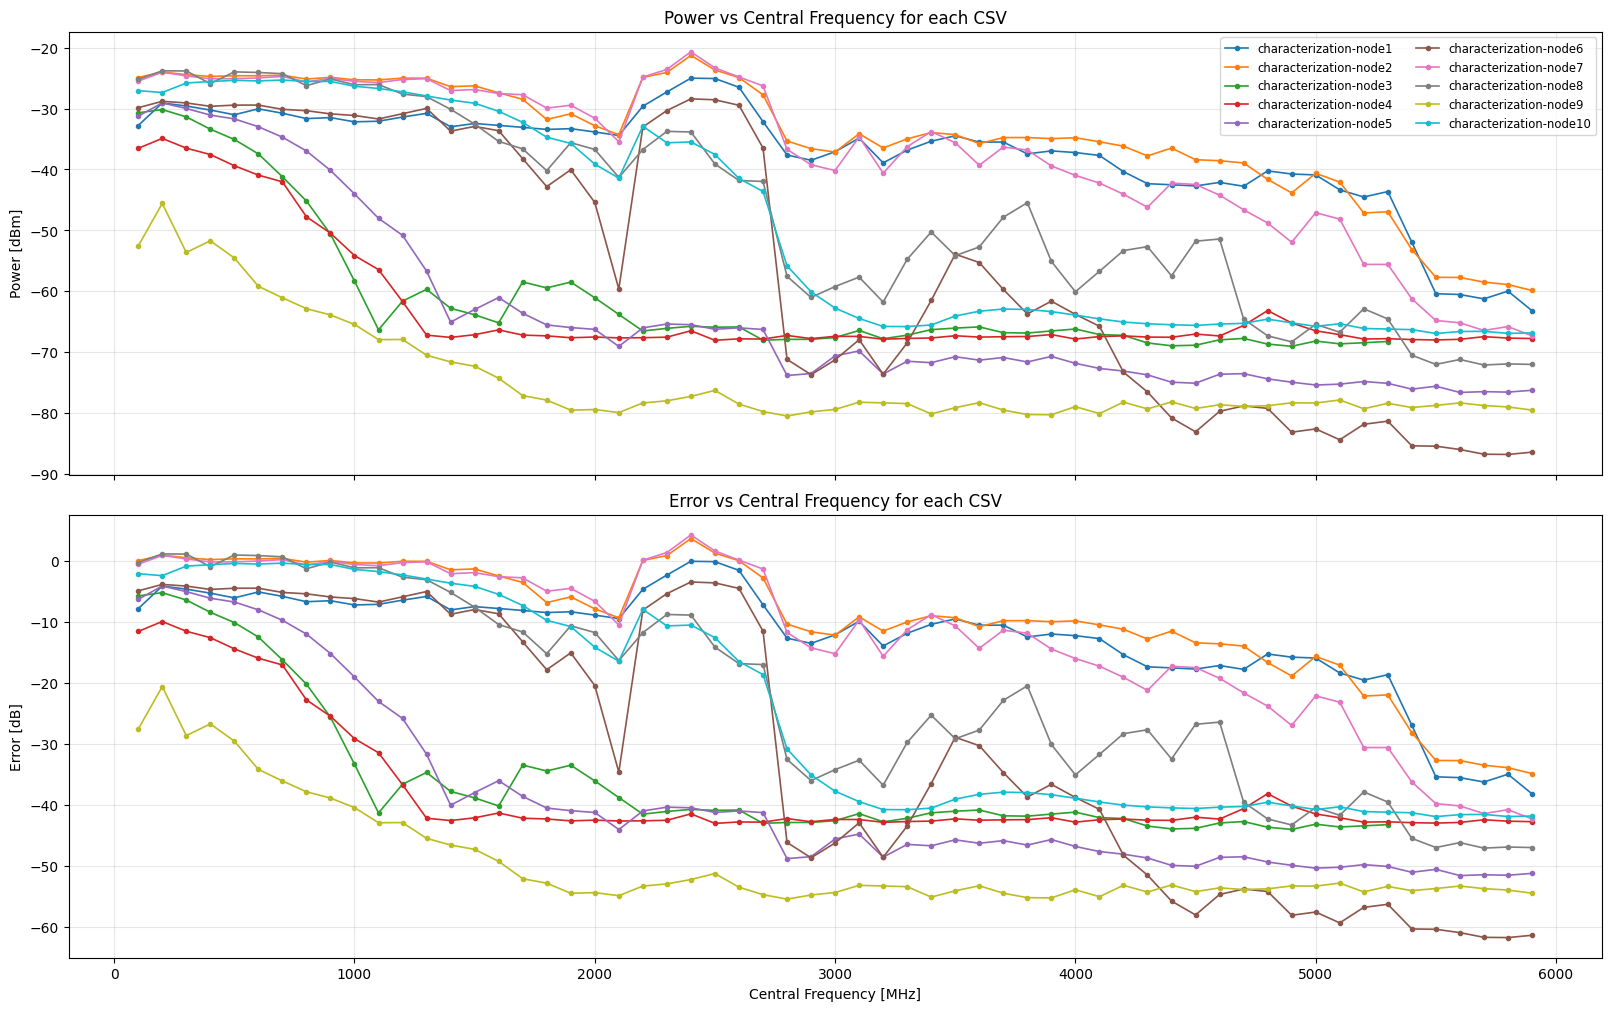

In [7]:
fig, (ax_power, ax_error) = plt.subplots(
    2,
    1,
    figsize=(16, 10),
    sharex=True,
    constrained_layout=True,
)

# Plot every run to compare shape and spread across frequencies.
for dataset_name, dataset_df in datasets.items():
    ax_power.plot(
        dataset_df["Frecuencia_central_MHz"],
        dataset_df["pwr_dBm"],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label=dataset_name,
    )
    ax_error.plot(
        dataset_df["Frecuencia_central_MHz"],
        dataset_df["error_dB"],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label=dataset_name,
    )

ax_power.set_title("Power vs Central Frequency for each CSV")
ax_power.set_ylabel("Power [dBm]")
ax_power.grid(True, alpha=0.3)
ax_power.legend(ncol=2, fontsize="small")

ax_error.set_title("Error vs Central Frequency for each CSV")
ax_error.set_xlabel("Central Frequency [MHz]")
ax_error.set_ylabel("Error [dB]")
ax_error.grid(True, alpha=0.3)

plt.show()


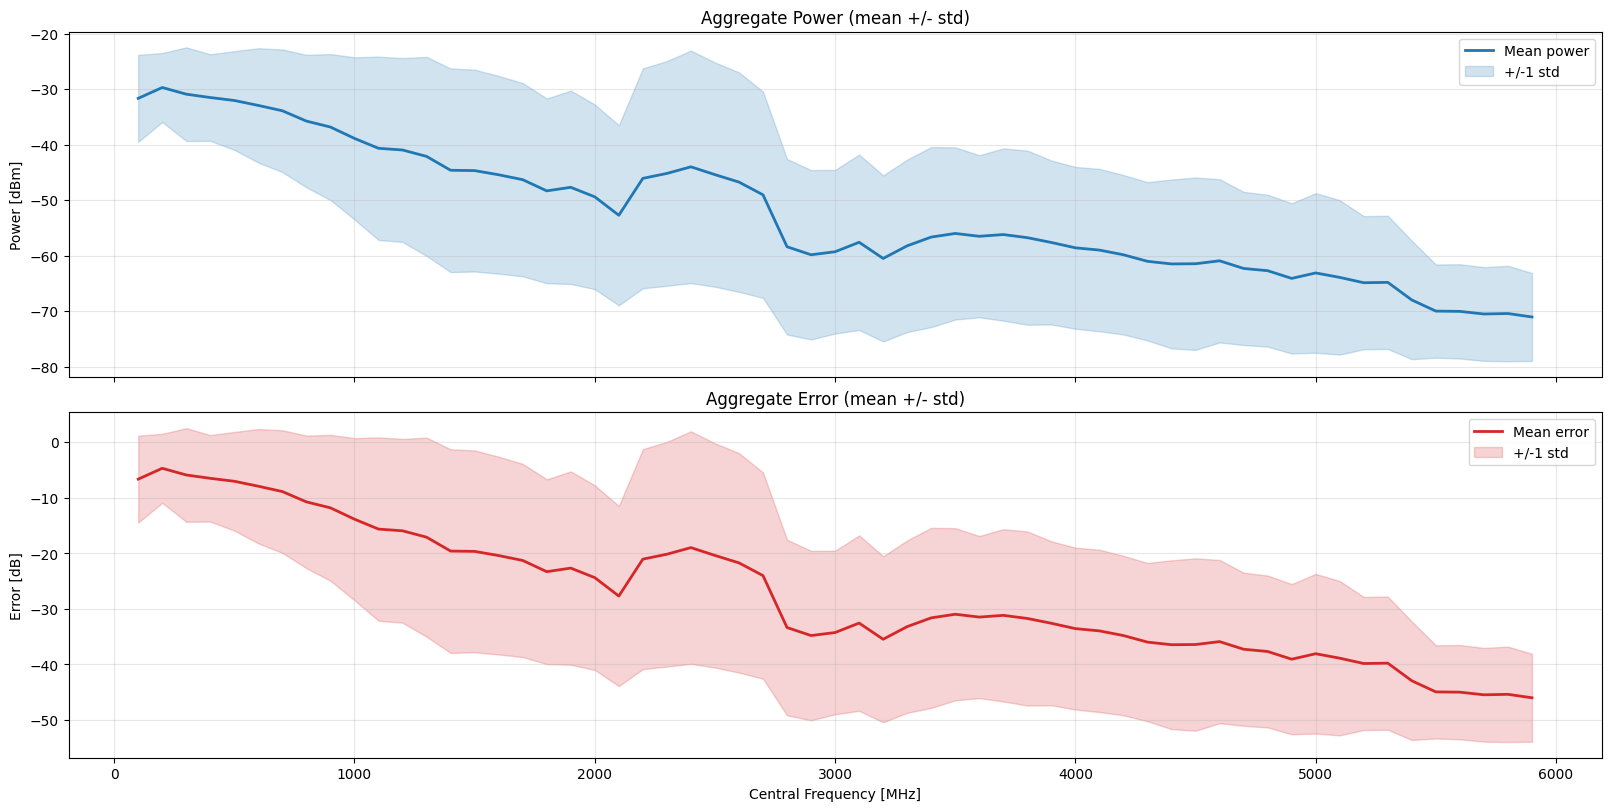

In [8]:
power_agg = build_frequency_aggregate(datasets, "pwr_dBm")
error_agg = build_frequency_aggregate(datasets, "error_dB")

fig, (ax_power, ax_error) = plt.subplots(
    2,
    1,
    figsize=(16, 8),
    sharex=True,
    constrained_layout=True,
)

# Aggregate view: mean curve with +/-1 standard deviation band.
ax_power.plot(
    power_agg["Frecuencia_central_MHz"],
    power_agg["mean"],
    color="tab:blue",
    linewidth=2,
    label="Mean power",
)
ax_power.fill_between(
    power_agg["Frecuencia_central_MHz"],
    power_agg["mean"] - power_agg["std"],
    power_agg["mean"] + power_agg["std"],
    color="tab:blue",
    alpha=0.2,
    label="+/-1 std",
)
ax_power.set_ylabel("Power [dBm]")
ax_power.set_title("Aggregate Power (mean +/- std)")
ax_power.grid(True, alpha=0.3)
ax_power.legend(loc="best")

ax_error.plot(
    error_agg["Frecuencia_central_MHz"],
    error_agg["mean"],
    color="tab:red",
    linewidth=2,
    label="Mean error",
)
ax_error.fill_between(
    error_agg["Frecuencia_central_MHz"],
    error_agg["mean"] - error_agg["std"],
    error_agg["mean"] + error_agg["std"],
    color="tab:red",
    alpha=0.2,
    label="+/-1 std",
)
ax_error.set_xlabel("Central Frequency [MHz]")
ax_error.set_ylabel("Error [dB]")
ax_error.set_title("Aggregate Error (mean +/- std)")
ax_error.grid(True, alpha=0.3)
ax_error.legend(loc="best")

plt.show()
